In [2]:
# ================ Cell 1: 先搞清楚 LFP 有哪些工况维度在变 ================
import glob, re, numpy as np, pandas as pd

# 你之前提取LFP时用的是 usable_batteries.csv, 里面有Temp/SOC/DOD
meta = pd.read_csv('usable_batteries.csv')
meta['bid'] = meta['bid'].apply(lambda x: f'{int(x):03d}')

print("LFP工况分布:")
print(f"  温度档: {sorted(meta['Temp'].unique())}")
print(f"  SOC档 : {sorted(meta['SOC'].unique())}")
print(f"  DOD档 : {sorted(meta['DOD'].unique())}")
print(f"  电池数: {len(meta)}")

# 关键判断: 温度在不在变
if meta['Temp'].nunique() == 1:
    print(f"\n⚠️ LFP全部 {meta['Temp'].iloc[0]}℃ 恒温 → 无法研究'温度混淆'")
    print("   能研究的是: 不同SOC/DOD组合是否导致特征相近")
else:
    print(f"\n✓ LFP有{meta['Temp'].nunique()}个温度档 → 可研究温度混淆")

LFP工况分布:
  温度档: [np.int64(15), np.int64(25), np.int64(35), np.int64(45)]
  SOC档 : [np.int64(10), np.int64(30), np.int64(50), np.int64(70), np.int64(90)]
  DOD档 : [np.int64(20), np.int64(40), np.int64(60), np.int64(80), np.int64(100)]
  电池数: 286

✓ LFP有4个温度档 → 可研究温度混淆


In [3]:
# ================ Cell 2: 建代表点 (每电池×每SOH层 → 一个特征均值向量) ================
import glob, re, numpy as np, pandas as pd
from scipy.spatial.distance import pdist, squareform

FEAT = ([f"Q_{i}" for i in range(16)] + [f"dQ_{i}" for i in range(16)] +
        [f"IC_{i}" for i in range(16)] + ["h_peak", "dVpeak"])
SOH_BINS = [(80,85),(85,90),(90,95),(95,100)]   # LFP老化到80%左右, 用这个范围

# 工况映射: bid(三位字符串) → dict
meta = pd.read_csv('usable_batteries.csv')
meta['bid'] = meta['bid'].apply(lambda x: f'{int(x):03d}')
COND = {r['bid']: dict(temp=int(r['Temp']), soc=int(r['SOC']), dod=int(r['DOD']))
        for _, r in meta.iterrows()}

reps = []
for f in sorted(glob.glob("X_train/X_*.csv")):
    bid = re.search(r"X_(\d+)", f).group(1)          # 保持三位, 和COND键一致
    if bid not in COND:
        continue
    d = pd.read_csv(f)
    for lo, hi in SOH_BINS:
        m = (d["SOH"] >= lo) & (d["SOH"] < hi)
        if m.sum() < 5:
            continue
        reps.append(dict(bid=bid, soh_bin=f"{lo}-{hi}",
                         soh_mean=d.loc[m,"SOH"].mean(),
                         vec=d.loc[m, FEAT].mean().values,
                         **COND[bid]))

print(f"共 {len(reps)} 个代表点, 来自 {len(set(r['bid'] for r in reps))} 颗电池")
# 自检: 工况必须取到, 不能是'?'
s = reps[0]
print(f"示例: 电池{s['bid']}, SOH{s['soh_mean']:.1f}%, {s['temp']}℃/{s['soc']}SOC/{s['dod']}DOD")
print(f"温度分布: {sorted(set(r['temp'] for r in reps))}")   # 应显示[15,25,35,45]

共 797 个代表点, 来自 244 颗电池
示例: 电池007, SOH82.2%, 35℃/70SOC/60DOD
温度分布: [15, 25, 35, 45]


In [4]:
# ================ Cell 3: 归一化 + 距离矩阵 (用训练同款min-max) ================
# 关键: 用训练时存的归一化参数, 距离矩阵才反映"网络眼中的距离"
norm = np.load("norm_lfp.npz")
x_min, x_max = norm['x_min'], norm['x_max']
span = np.where(x_max - x_min < 1e-12, 1.0, x_max - x_min)

X = np.array([r["vec"] for r in reps])
Xn = (X - x_min) / span                      # 和训练完全一致的min-max归一化
D = squareform(pdist(Xn, metric="euclidean"))
print(f"距离矩阵 {D.shape}, 距离范围 {D[D>0].min():.2f} ~ {D.max():.2f}")

def same_cond(a, b):
    return a["temp"]==b["temp"] and a["soc"]==b["soc"] and a["dod"]==b["dod"]

def lab(r):
    return f"{r['bid']}({r['temp']}℃/{r['soc']}SOC/{r['dod']}DOD,SOH{r['soh_bin']})"

距离矩阵 (797, 797), 距离范围 0.01 ~ 3.71


In [5]:
# ================ Cell 4: 事件A —— 相似SOH但不同工况, 特征却近? ================
# 这是老师问题的核心: 工况混淆的直接证据
print("=== A: SOH相近(±2%) + 工况不同, 但特征最近的10对 ===")
found = []
for i in range(len(reps)):
    for j in range(i+1, len(reps)):
        if abs(reps[i]["soh_mean"] - reps[j]["soh_mean"]) > 2: continue
        if same_cond(reps[i], reps[j]): continue          # 要工况不同
        found.append((D[i,j], i, j))
found.sort()
for d, i, j in found[:10]:
    print(f"  距离{d:.2f}: {lab(reps[i])}  ⟷  {lab(reps[j])}")
print(f"\n事件A共{len(found)}对, 最近距离{found[0][0]:.2f}, 中位{np.median([f[0] for f in found]):.2f}")

=== A: SOH相近(±2%) + 工况不同, 但特征最近的10对 ===
  距离0.01: 113(35℃/30SOC/40DOD,SOH95-100)  ⟷  133(35℃/50SOC/40DOD,SOH95-100)
  距离0.01: 133(35℃/50SOC/40DOD,SOH90-95)  ⟷  140(35℃/70SOC/40DOD,SOH90-95)
  距离0.01: 111(35℃/70SOC/20DOD,SOH85-90)  ⟷  125(35℃/10SOC/20DOD,SOH85-90)
  距离0.01: 113(35℃/30SOC/40DOD,SOH90-95)  ⟷  133(35℃/50SOC/40DOD,SOH90-95)
  距离0.01: 080(35℃/50SOC/20DOD,SOH95-100)  ⟷  177(35℃/30SOC/20DOD,SOH95-100)
  距离0.01: 014(35℃/70SOC/20DOD,SOH95-100)  ⟷  070(35℃/30SOC/20DOD,SOH95-100)
  距离0.01: 069(35℃/30SOC/20DOD,SOH85-90)  ⟷  087(35℃/50SOC/20DOD,SOH85-90)
  距离0.01: 124(35℃/30SOC/20DOD,SOH95-100)  ⟷  156(35℃/50SOC/20DOD,SOH95-100)
  距离0.01: 133(35℃/50SOC/40DOD,SOH80-85)  ⟷  140(35℃/70SOC/40DOD,SOH80-85)
  距离0.01: 090(35℃/30SOC/20DOD,SOH95-100)  ⟷  097(35℃/50SOC/20DOD,SOH95-100)

事件A共77941对, 最近距离0.01, 中位1.27


In [16]:
# ---- 分变量归因: 只让目标变量不同, 其余两个必须相同 ----

def probe_one_var(var):
    """只有var这个工况不同, 另两个相同, SOH相近 → 该变量的纯混淆效应"""
    others = [v for v in ['temp','soc','dod'] if v != var]
    pairs = []
    for i in range(len(reps)):
        for j in range(i+1, len(reps)):
            ri, rj = reps[i], reps[j]
            if abs(ri['soh_mean'] - rj['soh_mean']) > 2: continue   # SOH相近
            if ri[var] == rj[var]: continue                          # 目标变量必须不同
            if any(ri[o] != rj[o] for o in others): continue         # 其余必须相同
            pairs.append((D[i,j], i, j))
    if not pairs:
        print(f"[{var}不同, 其余相同] 无满足条件的对"); return
    dists = [p[0] for p in pairs]
    print(f"[仅{var}不同] {len(pairs)}对, 距离中位={np.median(dists):.3f}, 最近={min(dists):.3f}")
    return np.median(dists)

print("=== 分变量归因 (其余工况锁定, SOH相近) ===")
print(f"对照C(全同工况)中位距离: {med_c:.3f}\n")
m_temp = probe_one_var('temp')
m_soc  = probe_one_var('soc')
m_dod  = probe_one_var('dod')

=== 分变量归因 (其余工况锁定, SOH相近) ===
对照C(全同工况)中位距离: 0.094

[仅temp不同] 4735对, 距离中位=0.393, 最近=0.058
[仅soc不同] 5409对, 距离中位=0.204, 最近=0.007
[仅dod不同] 5929对, 距离中位=1.458, 最近=0.057


In [6]:
# ================ Cell 5: 事件C正对照 —— 相似SOH+相同工况应最近 ================
print("=== C: SOH相近(±2%) + 工况相同 (正对照, 应该最近) ===")
found_c = []
for i in range(len(reps)):
    for j in range(i+1, len(reps)):
        if abs(reps[i]["soh_mean"] - reps[j]["soh_mean"]) > 2: continue
        if not same_cond(reps[i], reps[j]): continue      # 要工况相同
        found_c.append((D[i,j], i, j))
med_c = np.median([f[0] for f in found_c]) if found_c else float('nan')
print(f"事件C共{len(found_c)}对, 距离中位{med_c:.2f}")

# ★ 关键裁决 ★
med_a = np.median([f[0] for f in found])
print(f"\n{'='*50}")
print(f"裁决: 事件A(不同工况)中位距离 {med_a:.2f}  vs  事件C(相同工况)中位 {med_c:.2f}")
if med_a < med_c * 1.3:
    print("⚠️ A≈C: 工况混淆显著! 不同工况的特征和相同工况一样近 → 老师担心成立")
else:
    print(f"✓ A明显>C: 换工况把特征推远了{med_a/med_c:.1f}倍 → 特征更多编码老化而非工况")

=== C: SOH相近(±2%) + 工况相同 (正对照, 应该最近) ===
事件C共2670对, 距离中位0.09

裁决: 事件A(不同工况)中位距离 1.27  vs  事件C(相同工况)中位 0.09
✓ A明显>C: 换工况把特征推远了13.4倍 → 特征更多编码老化而非工况


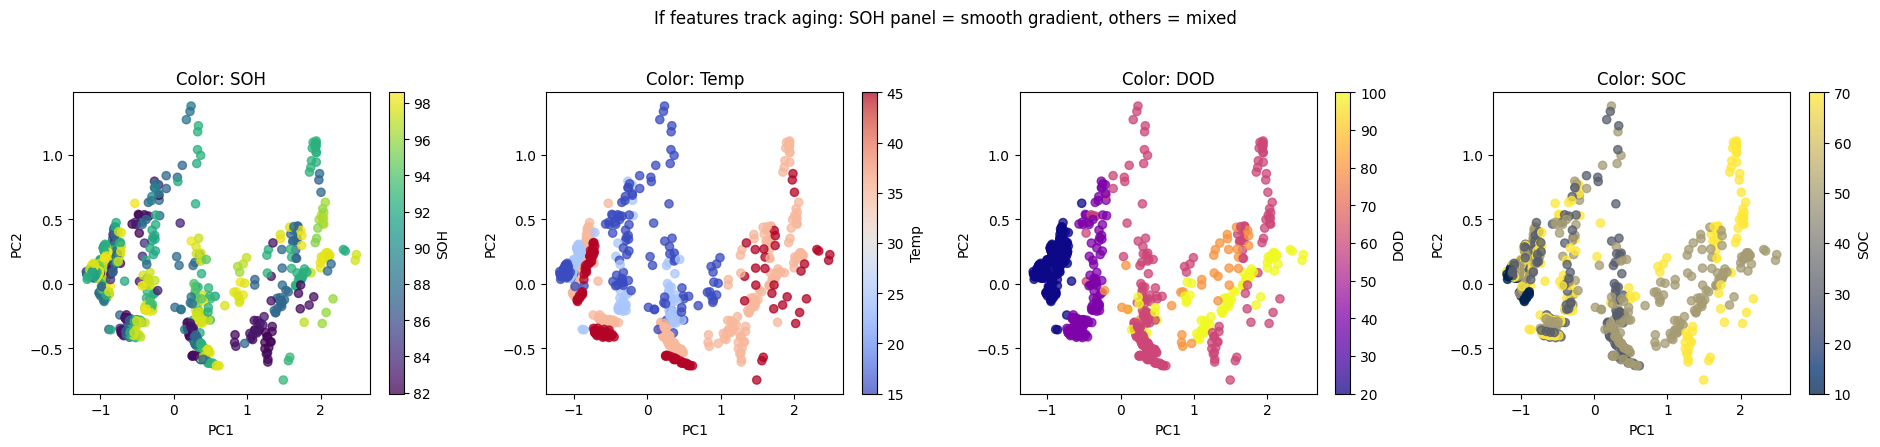

In [7]:
# ================ Cell 6: PCA可视化 —— 特征按SOH聚还是按工况聚 ================
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

Z = PCA(n_components=2).fit_transform(Xn)
fig, axes = plt.subplots(1, 4, figsize=(19, 4.3))
for ax, key, cmap, lbl in [
    (axes[0], "soh_mean", "viridis", "SOH"),
    (axes[1], "temp",     "coolwarm","Temp"),
    (axes[2], "dod",      "plasma",  "DOD"),
    (axes[3], "soc",      "cividis", "SOC")]:
    c = [r[key] for r in reps]
    s = ax.scatter(Z[:,0], Z[:,1], c=c, cmap=cmap, s=35, alpha=0.75)
    plt.colorbar(s, ax=ax, label=lbl)
    ax.set_title(f"Color: {lbl}"); ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
fig.suptitle("If features track aging: SOH panel = smooth gradient, others = mixed", y=1.03)
plt.tight_layout(); plt.savefig("lfp_confound_probe.png", dpi=180, bbox_inches='tight'); plt.show()

In [8]:
temp_diff_pairs = [(d,i,j) for d,i,j in found[:100] if reps[i]['temp']!=reps[j]['temp']]
print(f"最近100对中, 温度不同的有 {len(temp_diff_pairs)} 对")
for d,i,j in temp_diff_pairs[:5]:
    print(f"  距离{d:.2f}: {lab(reps[i])} ⟷ {lab(reps[j])}")

最近100对中, 温度不同的有 0 对


In [17]:
# ---- 实验: 工况差异 vs 特征距离, 找"工况差很大但特征很近"的危险对 ----
# 先定义两个代表点之间的"工况距离"(归一化后, 三维工况空间的欧氏距离)
def cond_vec(r):
    # 把温度/SOC/DOD各自归一化到可比尺度(除以各自量程)
    return np.array([r['temp']/45, r['soc']/90, r['dod']/100])

danger = []      # 工况差大 + 特征差小 的对
for i in range(len(reps)):
    for j in range(i+1, len(reps)):
        ri, rj = reps[i], reps[j]
        cond_d = np.linalg.norm(cond_vec(ri) - cond_vec(rj))   # 工况距离
        feat_d = D[i,j]                                          # 特征距离
        danger.append((cond_d, feat_d, i, j))

danger = np.array([(c,f) for c,f,_,_ in danger])
cond_ds, feat_ds = danger[:,0], danger[:,1]

# 相关性: 工况距离和特征距离应该正相关(工况差越大特征差越大)
from scipy.stats import spearmanr
rho, _ = spearmanr(cond_ds, feat_ds)
print(f"工况距离 vs 特征距离 的Spearman相关: {rho:+.3f}")
print("  接近+1 → 特征忠实编码工况, 无抵消")
print("  接近 0 → 工况和特征脱节, 可能存在组合抵消")

# 危险象限: 工况距离在最大的25%, 但特征距离在最小的25%
c_hi = np.percentile(cond_ds, 75)   # 工况差大
f_lo = np.percentile(feat_ds, 25)   # 特征差小
n_danger = np.sum((cond_ds > c_hi) & (feat_ds < f_lo))
print(f"\n危险象限(工况差大+特征差小)的对数: {n_danger} / {len(cond_ds)} "
      f"({100*n_danger/len(cond_ds):.2f}%)")

工况距离 vs 特征距离 的Spearman相关: +0.513
  接近+1 → 特征忠实编码工况, 无抵消
  接近 0 → 工况和特征脱节, 可能存在组合抵消

危险象限(工况差大+特征差小)的对数: 7598 / 317206 (2.40%)


C:\Users\zho-xli\AppData\Local\Temp\ipykernel_14620\1631737034.py:9: UserWarning: Glyph 24037 (\N{CJK UNIFIED IDEOGRAPH-5DE5}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.tight_layout(); plt.savefig('cond_vs_feat.png', dpi=180); plt.show()
C:\Users\zho-xli\AppData\Local\Temp\ipykernel_14620\1631737034.py:9: UserWarning: Glyph 20917 (\N{CJK UNIFIED IDEOGRAPH-51B5}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.tight_layout(); plt.savefig('cond_vs_feat.png', dpi=180); plt.show()
C:\Users\zho-xli\AppData\Local\Temp\ipykernel_14620\1631737034.py:9: UserWarning: Glyph 36317 (\N{CJK UNIFIED IDEOGRAPH-8DDD}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.tight_layout(); plt.savefig('cond_vs_feat.png', dpi=180); plt.show()
C:\Users\zho-xli\AppData\Local\Temp\ipykernel_14620\1631737034.py:9: UserWarning: Glyph 31163 (\N{CJK UNIFIED IDEOGRAPH-79BB}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.tight_layout(); plt.savefig('cond_vs_feat.png', dpi=180); plt.show()


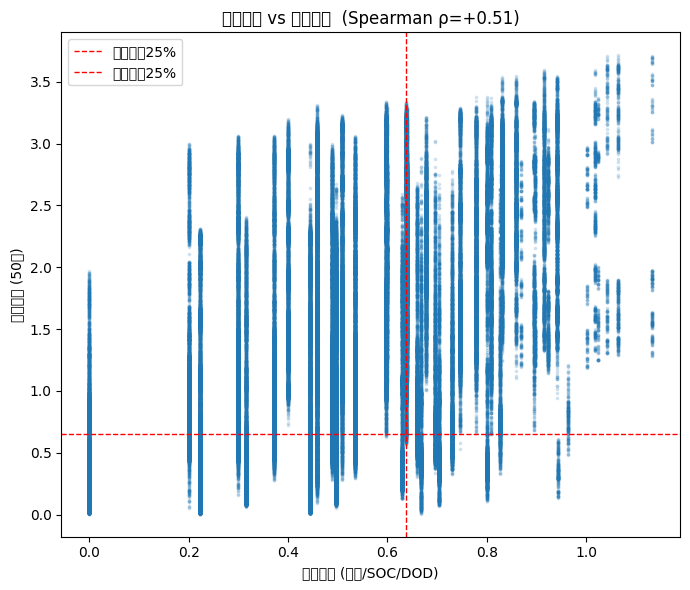


=== 最危险的对: 工况差大但特征几乎相同 ===
  特征距0.01 工况距0.67: 111(35℃/70/20DOD,SOH89) ⟷ 125(35℃/10/20DOD,SOH90)
  特征距0.01 工况距0.67: 185(15℃/70/20DOD,SOH88) ⟷ 461(15℃/10/20DOD,SOH93)
  特征距0.02 工况距0.67: 185(15℃/70/20DOD,SOH88) ⟷ 469(15℃/10/20DOD,SOH93)
  特征距0.02 工况距0.67: 111(35℃/70/20DOD,SOH89) ⟷ 127(35℃/10/20DOD,SOH89)
  特征距0.02 工况距0.67: 111(35℃/70/20DOD,SOH89) ⟷ 126(35℃/10/20DOD,SOH89)
  特征距0.03 工况距0.67: 185(15℃/70/20DOD,SOH85) ⟷ 189(15℃/10/20DOD,SOH88)
  特征距0.03 工况距0.67: 110(35℃/70/20DOD,SOH89) ⟷ 138(35℃/10/20DOD,SOH93)
  特征距0.03 工况距0.67: 111(35℃/70/20DOD,SOH89) ⟷ 125(35℃/10/20DOD,SOH93)
  特征距0.03 工况距0.67: 111(35℃/70/20DOD,SOH89) ⟷ 127(35℃/10/20DOD,SOH93)
  特征距0.03 工况距0.67: 110(35℃/70/20DOD,SOH89) ⟷ 125(35℃/10/20DOD,SOH93)


In [18]:
# ---- 可视化 + 揪出最危险的具体案例 ----
import matplotlib.pyplot as plt
plt.figure(figsize=(7,6))
plt.scatter(cond_ds, feat_ds, s=3, alpha=0.15)
plt.axvline(c_hi, color='r', ls='--', lw=1, label='工况差前25%')
plt.axhline(f_lo, color='r', ls='--', lw=1, label='特征差后25%')
plt.xlabel('工况距离 (温度/SOC/DOD)'); plt.ylabel('特征距离 (50维)')
plt.title(f'工况差异 vs 特征差异  (Spearman ρ={rho:+.2f})')
plt.legend(); plt.tight_layout(); plt.savefig('cond_vs_feat.png', dpi=180); plt.show()

# 找最危险的10对: 工况差最大的里面, 特征差最小的
idx_all = [(c,f,i,j) for (c,f),(_,_,i,j) in
           zip([(c,f) for c,f in zip(cond_ds,feat_ds)],
               [(0,0,i,j) for i in range(len(reps)) for j in range(i+1,len(reps))])]
# 重新收集(上面数组丢了ij, 这里重算)
danger_pairs = []
for i in range(len(reps)):
    for j in range(i+1, len(reps)):
        ri, rj = reps[i], reps[j]
        cd = np.linalg.norm(cond_vec(ri)-cond_vec(rj))
        if cd > c_hi and D[i,j] < f_lo:
            danger_pairs.append((D[i,j], cd, i, j))
danger_pairs.sort()   # 特征距离最小的排前
print(f"\n=== 最危险的对: 工况差大但特征几乎相同 ===")
for fd, cd, i, j in danger_pairs[:10]:
    ri, rj = reps[i], reps[j]
    print(f"  特征距{fd:.2f} 工况距{cd:.2f}: "
          f"{ri['bid']}({ri['temp']}℃/{ri['soc']}/{ri['dod']}DOD,SOH{ri['soh_mean']:.0f}) ⟷ "
          f"{rj['bid']}({rj['temp']}℃/{rj['soc']}/{rj['dod']}DOD,SOH{rj['soh_mean']:.0f})")

In [19]:
# 危险对里, SOH也相近的(良性) vs SOH差大的(恶性)
benign = sum(1 for fd,cd,i,j in danger_pairs if abs(reps[i]['soh_mean']-reps[j]['soh_mean'])<=2)
malign = sum(1 for fd,cd,i,j in danger_pairs if abs(reps[i]['soh_mean']-reps[j]['soh_mean'])>5)
print(f"\n危险象限{len(danger_pairs)}对中: SOH相近(良性){benign}对, SOH差>5%(恶性){malign}对")


危险象限7598对中: SOH相近(良性)2056对, SOH差>5%(恶性)3658对


In [20]:
# ---- 排除已知无害因素后, 看真正的组合混淆还剩多少 ----
# 排除标准:
#   1) 任一电池是20DOD → 弱信号区, 已由window判据处理
#   2) 两电池仅SOC不同(温度、DOD都相同) → SOC单变量, 已证无害
# 剩下的才是"真正多变量组合导致的撞脸"

def only_soc_differs(a, b):
    return a['temp']==b['temp'] and a['dod']==b['dod'] and a['soc']!=b['soc']

# 在所有"特征近"的对里(特征距<f_lo), 分类统计
f_lo = np.percentile(D[np.triu_indices(len(reps),1)], 25)   # 特征距最近25%阈值

near_pairs = []
for i in range(len(reps)):
    for j in range(i+1, len(reps)):
        if D[i,j] >= f_lo: continue                # 只看特征相近的对
        near_pairs.append((i,j))

# 分类
excluded_20dod = 0
excluded_soc   = 0
real_combo     = []          # 真正的多变量组合撞脸
for i,j in near_pairs:
    ri, rj = reps[i], reps[j]
    if ri['dod']==20 or rj['dod']==20:
        excluded_20dod += 1
    elif only_soc_differs(ri, rj):
        excluded_soc += 1
    elif same_cond(ri, rj):
        continue                                    # 同工况本就该近, 不算问题
    else:
        real_combo.append((D[i,j], i, j))

print(f"特征相近的对总数: {len(near_pairs)}")
print(f"  排除(含20DOD弱信号): {excluded_20dod}")
print(f"  排除(仅SOC不同,已证无害): {excluded_soc}")
print(f"  → 真正的多变量组合撞脸: {len(real_combo)}")

# 这些"真正组合撞脸"里, 有多少SOH还差很大(恶性)?
real_malign = [(fd,i,j) for fd,i,j in real_combo
               if abs(reps[i]['soh_mean']-reps[j]['soh_mean'])>5]
print(f"\n其中SOH差>5%的恶性对: {len(real_malign)}")
if real_malign:
    print("最恶性的10对(排除20DOD和纯SOC后):")
    for fd,i,j in sorted(real_malign)[:10]:
        ri,rj = reps[i],reps[j]
        print(f"  特征距{fd:.2f}: {ri['bid']}({ri['temp']}℃/{ri['soc']}/{ri['dod']}DOD,SOH{ri['soh_mean']:.0f}) ⟷ "
              f"{rj['bid']}({rj['temp']}℃/{rj['soc']}/{rj['dod']}DOD,SOH{rj['soh_mean']:.0f})")
else:
    print("✓ 排除已知无害因素后, 无恶性组合撞脸 → 组合混淆假设被证伪")

特征相近的对总数: 79302
  排除(含20DOD弱信号): 54066
  排除(仅SOC不同,已证无害): 4297
  → 真正的多变量组合撞脸: 15659

其中SOH差>5%的恶性对: 8436
最恶性的10对(排除20DOD和纯SOC后):
  特征距0.07: 137(35℃/50/40DOD,SOH92) ⟷ 223(45℃/50/40DOD,SOH98)
  特征距0.08: 112(35℃/30/40DOD,SOH92) ⟷ 223(45℃/50/40DOD,SOH98)
  特征距0.08: 137(35℃/50/40DOD,SOH87) ⟷ 223(45℃/50/40DOD,SOH92)
  特征距0.09: 112(35℃/30/40DOD,SOH87) ⟷ 223(45℃/50/40DOD,SOH92)
  特征距0.09: 109(35℃/30/40DOD,SOH88) ⟷ 223(45℃/50/40DOD,SOH98)
  特征距0.09: 073(25℃/50/40DOD,SOH88) ⟷ 460(15℃/30/40DOD,SOH97)
  特征距0.09: 141(35℃/50/40DOD,SOH84) ⟷ 223(45℃/50/40DOD,SOH92)
  特征距0.09: 137(35℃/50/40DOD,SOH83) ⟷ 223(45℃/50/40DOD,SOH88)
  特征距0.09: 133(35℃/50/40DOD,SOH92) ⟷ 223(45℃/50/40DOD,SOH98)
  特征距0.09: 073(25℃/50/40DOD,SOH88) ⟷ 456(15℃/50/40DOD,SOH97)


In [21]:
# 8436个恶性对里, 温度不同的占多少?
real_malign_all = [(i,j) for fd,i,j in real_combo
                   if abs(reps[i]['soh_mean']-reps[j]['soh_mean'])>5]
n_temp = sum(1 for i,j in real_malign_all if reps[i]['temp']!=reps[j]['temp'])
print(f"恶性组合对 {len(real_malign_all)} 个中, 温度不同的: {n_temp} "
      f"({100*n_temp/len(real_malign_all):.0f}%)")

恶性组合对 8436 个中, 温度不同的: 7495 (89%)


In [9]:
# 只用25℃的LFP电池重训源域模型, 对比全温度版的迁移表现
cells_25 = [b for b,c in COND.items() if c['temp']==25]
print(f"25℃电池数: {len(cells_25)} / {len(COND)}")
# → 用这批重训, 迁移后比全温度版的NCA RMSE

25℃电池数: 61 / 286


In [12]:
# ---- 25℃-only 源域: 训练和测试都限定25℃ ----
cells_25 = set(b for b,c in COND.items() if c['temp']==25)
# 补上特征列定义(和NB1一致)
FEAT_COLS = ([f"Q_{i}" for i in range(16)] + [f"dQ_{i}" for i in range(16)] +
             [f"IC_{i}" for i in range(16)] + ["h_peak", "dVpeak"])
def load_25(x_dir, y_dir=None):
    Xs, ys, bids = [], [], []
    for f in sorted(glob.glob(f"{x_dir}/X_*.csv")):
        bid = re.search(r"X_(\d+)", f).group(1)
        if bid not in cells_25: continue          # ← 只要25℃
        x = pd.read_csv(f)
        if y_dir is None:
            y = x["SOH"].to_numpy(np.float32)
        else:
            y = pd.read_csv(f"{y_dir}/y_{bid}.csv")["SOH"].to_numpy(np.float32)
        Xs.append(x[FEAT_COLS].to_numpy(np.float32)); ys.append(y)
        bids.append(np.full(len(x), bid))
    if not Xs:
        print(f"{x_dir}: 无25℃电池"); return None,None,None
    X,y,b = np.concatenate(Xs),np.concatenate(ys),np.concatenate(bids)
    print(f"{x_dir}(25℃): {len(np.unique(b))}颗, {len(X)}行")
    return X,y,b

X_all,y_all,bid_all = load_25("X_train")
Xte,yte,bid_te = load_25("X_test_noleak", "y_test_secret")
# 若测试集25℃电池太少, 就从训练集里再分一部分25℃电池做测试

X_train(25℃): 51颗, 301976行
X_test_noleak(25℃): 7颗, 31706行


In [13]:
# ---- 25℃-only: 归一化 + 切验证集 + loaders ----
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

SEED=42; VAL_FRAC=0.12; Y_LO,Y_HI=50.0,105.0
BATCH=256; DEV="cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(SEED); np.random.seed(SEED)

# 验证集: 从25℃训练电池里切
cells=np.unique(bid_all); rng=np.random.default_rng(SEED); rng.shuffle(cells)
m_va=np.isin(bid_all, cells[:max(1,int(len(cells)*VAL_FRAC))])
Xtr,ytr=X_all[~m_va],y_all[~m_va]
Xva,yva=X_all[m_va], y_all[m_va]

# 归一化: 只在25℃训练集上拟合(新的一套, 不复用混温度的norm_lfp)
x_min=Xtr.min(0); x_max=Xtr.max(0)
span=np.where(x_max-x_min<1e-12,1.0,x_max-x_min)
norm_x=lambda X:((X-x_min)/span).astype(np.float32)
norm_y=lambda y:((y-Y_LO)/(Y_HI-Y_LO)).astype(np.float32)
denorm_y=lambda yn:yn*(Y_HI-Y_LO)+Y_LO
mk=lambda X,y,sh:DataLoader(TensorDataset(torch.from_numpy(norm_x(X)),
                            torch.from_numpy(norm_y(y))),batch_size=BATCH,shuffle=sh)
tr_loader=mk(Xtr,ytr,True); va_loader=mk(Xva,yva,False); te_loader=mk(Xte,yte,False)
np.savez("norm_lfp_25C.npz", x_min=x_min, x_max=x_max, y_lo=Y_LO, y_hi=Y_HI)
print(f"train {len(np.unique(bid_all[~m_va]))}颗 / val {len(np.unique(bid_all[m_va]))}颗 / test {len(np.unique(bid_te))}颗")

train 45颗 / val 6颗 / test 7颗


In [14]:
# ---- SOHNet (和NB1完全一致) ----
class SOHNet(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.conv=nn.Sequential(
            nn.Conv1d(3,32,3,padding=1),nn.ReLU(),nn.BatchNorm1d(32),
            nn.Conv1d(32,64,3,padding=1),nn.ReLU(),nn.BatchNorm1d(64),
            nn.AdaptiveAvgPool1d(4))
        self.head=nn.Sequential(
            nn.Linear(64*4+2,128),nn.ReLU(),nn.Dropout(dropout),
            nn.Linear(128,32),nn.ReLU(),nn.Dropout(dropout),
            nn.Linear(32,1))
    def forward(self,x):
        f=self.conv(x[:,:48].reshape(-1,3,16)).flatten(1)
        return self.head(torch.cat([f,x[:,48:]],1)).squeeze(-1)

model=SOHNet().to(DEV)
opt=torch.optim.Adam(model.parameters(),lr=3e-4,weight_decay=1e-4)
sch=torch.optim.lr_scheduler.ReduceLROnPlateau(opt,'min',factor=0.5,patience=8,min_lr=1e-6)

def eval_rmse(loader):
    model.eval(); errs=[]
    with torch.no_grad():
        for xb,yb in loader:
            p=model(xb.to(DEV)).cpu().numpy()
            errs.append((denorm_y(p)-denorm_y(yb.numpy()))**2)
    return float(np.sqrt(np.concatenate(errs).mean()))

In [15]:
# ---- 训练(早停) ----
best,bad=1e9,0
for ep in range(1,301):
    model.train()
    for xb,yb in tr_loader:
        opt.zero_grad()
        nn.functional.mse_loss(model(xb.to(DEV)),yb.to(DEV)).backward(); opt.step()
    v=eval_rmse(va_loader); sch.step(v)
    if v<best-1e-4: best,bad=v,0; torch.save(model.state_dict(),"sohnet_lfp_25C.pt")
    else: bad+=1
    if ep%10==0 or bad==0: print(f"ep{ep:3d} val RMSE {v:.3f}% (best {best:.3f}%)")
    if bad>=40: print(f"early stop @ ep{ep}"); break

ep  1 val RMSE 48.757% (best 48.757%)
ep  2 val RMSE 29.178% (best 29.178%)
ep  3 val RMSE 16.803% (best 16.803%)
ep  4 val RMSE 7.542% (best 7.542%)
ep  5 val RMSE 4.329% (best 4.329%)
ep  6 val RMSE 3.131% (best 3.131%)
ep  7 val RMSE 2.956% (best 2.956%)
ep 10 val RMSE 5.931% (best 2.956%)
ep 20 val RMSE 5.828% (best 2.956%)
ep 29 val RMSE 2.898% (best 2.898%)
ep 30 val RMSE 2.994% (best 2.898%)
ep 32 val RMSE 2.874% (best 2.874%)
ep 33 val RMSE 2.736% (best 2.736%)
ep 34 val RMSE 2.718% (best 2.718%)
ep 38 val RMSE 2.709% (best 2.709%)
ep 40 val RMSE 2.664% (best 2.664%)
ep 42 val RMSE 2.648% (best 2.648%)
ep 43 val RMSE 2.611% (best 2.611%)
ep 46 val RMSE 2.606% (best 2.606%)
ep 47 val RMSE 2.570% (best 2.570%)
ep 48 val RMSE 2.565% (best 2.565%)
ep 50 val RMSE 2.553% (best 2.553%)


KeyboardInterrupt: 

In [ ]:
# ---- 盲测(25℃) + 与混温度版对比 ----
model.load_state_dict(torch.load("sohnet_lfp_25C.pt")); model.eval()
preds,trues=[],[]
with torch.no_grad():
    for xb,yb in te_loader:
        preds.append(denorm_y(model(xb.to(DEV)).cpu().numpy()))
        trues.append(denorm_y(yb.numpy()))
preds,trues=np.concatenate(preds),np.concatenate(trues)
rmse=float(np.sqrt(((preds-trues)**2).mean()))
r2=1-((preds-trues)**2).sum()/((trues-trues.mean())**2).sum()
print(f"\n{'='*50}")
print(f"25℃-only 源域盲测: RMSE={rmse:.3f}%  R²={r2:.4f}  (7颗25℃电池)")
print(f"对比 混温度版:      RMSE≈?      R²≈0.95   ← 填你之前的数字")
print(f"{'='*50}")